Starting Quantum Denoising Training...
Epoch 0 | Fidelity: 0.4991 | Angle: 3.0899
Epoch 10 | Fidelity: 0.2062 | Angle: 2.4343
Epoch 20 | Fidelity: 0.0002 | Angle: 1.5021
Epoch 30 | Fidelity: 0.1933 | Angle: 0.5796
Epoch 40 | Fidelity: 0.5007 | Angle: -0.0516
Training Complete. Noise Reversed.


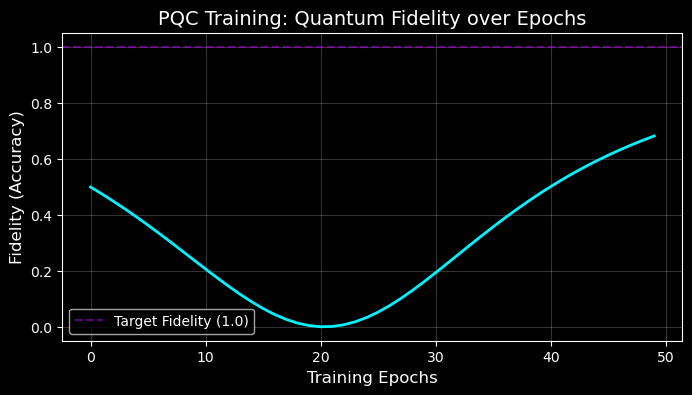

In [5]:
import numpy as np
import matplotlib.pyplot as plt


clean_state = np.array([1.0, 0.0])
noisy_state = np.array([0.707, 0.707])

def apply_recoherence_gate(state, theta):
    rotation_matrix = np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2),  np.cos(theta/2)]
    ])
    return np.dot(rotation_matrix, state)

def calculate_fidelity(state_a, state_b):
    return np.abs(np.dot(state_a, state_b))**2

# --- THE TRAINING LOOP (Gradient Descent) ---
theta_guess = 3.14
learning_rate = 0.1
fidelities = []

print("Starting Quantum Denoising Training...")

for epoch in range(50):
    predicted_state = apply_recoherence_gate(noisy_state, theta_guess)
    fidelity = calculate_fidelity(predicted_state, clean_state)
    fidelities.append(fidelity)

    error = 1.0 - fidelity
    theta_guess -= learning_rate * error

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Fidelity: {fidelity:.4f} | Angle: {theta_guess:.4f}")

print("Training Complete. Noise Reversed.")

# Plot the Learning Curve
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))
plt.plot(range(len(fidelities)), fidelities, color='#00f3ff', linewidth=2)  # ← fixed
plt.title("PQC Training: Quantum Fidelity over Epochs", fontsize=14)
plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Fidelity (Accuracy)", fontsize=12)
plt.axhline(y=1.0, color='#bd00ff', linestyle='--', alpha=0.5, label='Target Fidelity (1.0)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()